In [1]:
%cd ../
%load_ext autoreload
%autoreload 2

/Users/matthaei/Documents/code/python/bachelor-project


In [2]:
MIGRATE_DATABASE = True

In [25]:
from src.measurements.measurement_service import MeasurementService
from src.weather_stations.weather_station_service import WeatherStationService
from src.wind_turbines.wind_turbines_service import WindTurbinesService
from src.calculation.calculation_service import CalculationService
from src.model.variant.bilstm_model import BiLSTMModel
from src.prediction.prediction_service import PredictionService
from src.database.database_service import DatabaseService
from src.model.model_service import ModelService
from omegaconf import DictConfig, OmegaConf
from hydra import compose, initialize_config_dir
import os
from datetime import datetime

In [4]:
# Initialize Hydra configuration
config_dir = os.path.abspath("./conf")

# Initialize Hydra with the config directory
with initialize_config_dir(config_dir=config_dir, version_base=None):
    cfg = compose(config_name="config")

In [5]:
database_service = DatabaseService(cfg)

if MIGRATE_DATABASE:
    database_service.create_tables()

2025-09-13 15:26:40.357 | INFO     | src.database.database_service:create_tables:22 - Tables created


In [6]:
weather_station_service = WeatherStationService(cfg, database_service)
weather_stations_df = weather_station_service.load_from_database()

2025-09-13 15:26:41.276 | INFO     | src.weather_stations.weather_station_data_provider:load_from_database:228 - Loaded 50 weather stations from database


In [7]:
measurement_service = MeasurementService(cfg, database_service, weather_stations_df)

In [8]:
model_service = ModelService(cfg, database_service, measurement_service)

In [9]:
lstm = BiLSTMModel()

In [10]:
lstm.load('models/good_lstm/')

In [11]:
model_service.attach_model(lstm)

## Get Predictions


In [105]:
prediction_service = PredictionService(cfg, database_service, measurement_service, model_service)

In [110]:
measurements_df = prediction_service.predict_measurements()

2025-09-13 18:05:39.659 | INFO     | src.measurements.measurement_service:load_all_recent_measurements_from_database:121 - Loading all recent measurements from database
2025-09-13 18:05:39.992 | INFO     | src.measurements.measurement_data_provider:load_measurements_from_database:240 - Loaded chunk of 3600 rows (total so far: 3600)
2025-09-13 18:05:40.070 | INFO     | src.measurements.measurement_data_provider:load_measurements_from_database:249 - Loaded 3600 measurements from database
2025-09-13 18:05:40.071 | INFO     | src.measurements.measurement_service:load_all_recent_measurements_from_database:123 - Loaded 3600 recent measurements from database
2025-09-13 18:05:40.683 | INFO     | src.prediction.prediction_data_provider:save_predictions_to_database:56 - Upserted 200 predictions to database
2025-09-13 18:05:40.799 | INFO     | src.prediction.prediction_data_provider:save_predictions_to_database:56 - Upserted 200 predictions to database
2025-09-13 18:05:41.053 | INFO     | src.pre

In [111]:
measurements_df

,station_id,record_date,u,v,is_prediction
0,96,2025-09-13 03:30:00,-0.800000,-4.898587e-17,False
72,164,2025-09-13 03:30:00,-1.414133,1.685298e+00,False
144,303,2025-09-13 03:30:00,-2.255262,8.208483e-01,False
216,400,2025-09-13 03:30:00,986.700652,1.562780e+02,False
288,403,2025-09-13 03:30:00,NaN,NaN,False
...,...,...,...,...,...
3311,6265,2025-09-14 03:20:00,-0.466865,-6.027940e-01,True
3383,6273,2025-09-14 03:20:00,-0.593025,-7.370980e-01,True
3455,7351,2025-09-14 03:20:00,-0.592506,-7.361367e-01,True
3527,7389,2025-09-14 03:20:00,-0.571602,-7.139505e-01,True


In [112]:
single_station_df = measurements_df[measurements_df["station_id"] == 96]

single_station_df

,station_id,record_date,u,v,is_prediction
0,96,2025-09-13 03:30:00,-0.800000,-4.898587e-17,False
1,96,2025-09-13 03:40:00,-0.984808,-1.736482e-01,False
2,96,2025-09-13 03:50:00,-0.689365,-1.215537e-01,False
3,96,2025-09-13 04:00:00,-0.751754,-2.736161e-01,False
4,96,2025-09-13 04:10:00,-0.492404,-8.682409e-02,False
...,...,...,...,...,...
67,96,2025-09-14 02:40:00,-0.586525,-7.242730e-01,True
68,96,2025-09-14 02:50:00,-0.586464,-7.263215e-01,True
69,96,2025-09-14 03:00:00,-0.581459,-7.248376e-01,True
70,96,2025-09-14 03:10:00,-0.581459,-7.246926e-01,True


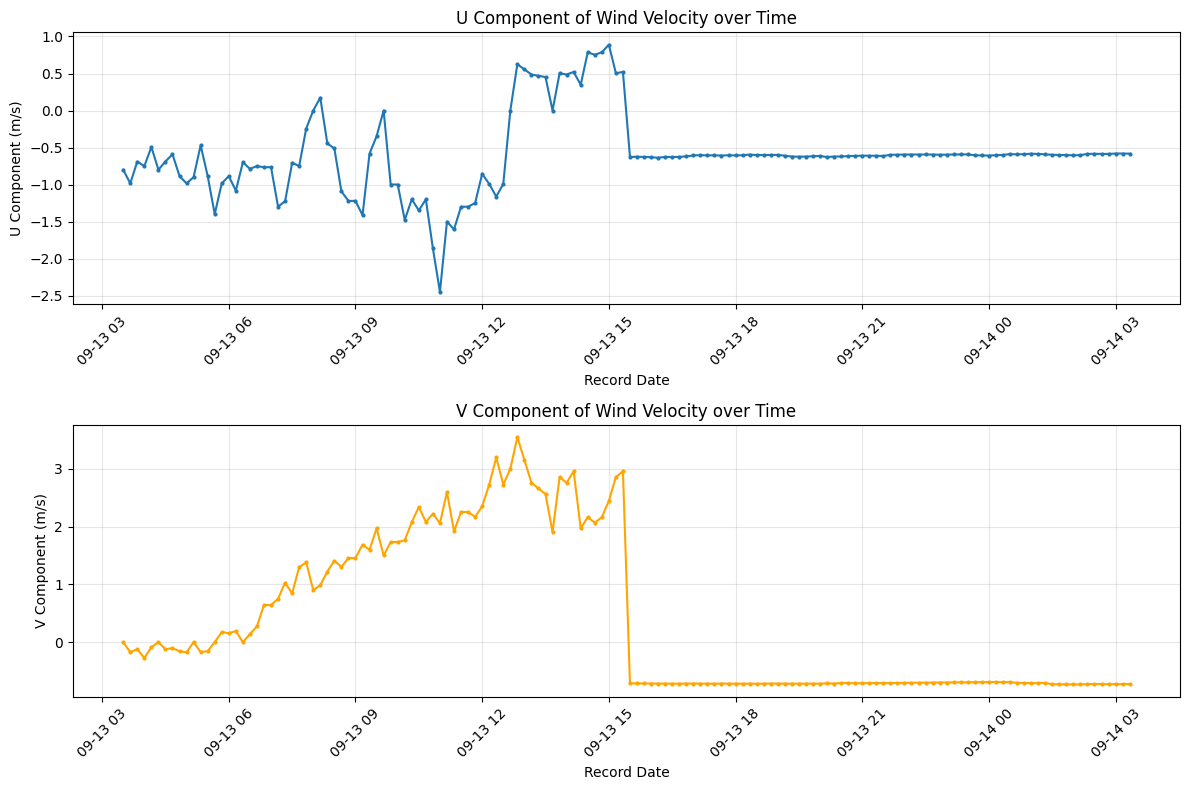

In [113]:
import matplotlib.pyplot as plt

# Create subplots for u and v components
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot u component
ax1.plot(single_station_df['record_date'], single_station_df['u'], marker='o', markersize=2)
ax1.set_title('U Component of Wind Velocity over Time')
ax1.set_xlabel('Record Date')
ax1.set_ylabel('U Component (m/s)')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Plot v component
ax2.plot(single_station_df['record_date'], single_station_df['v'], marker='o', markersize=2, color='orange')
ax2.set_title('V Component of Wind Velocity over Time')
ax2.set_xlabel('Record Date')
ax2.set_ylabel('V Component (m/s)')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [114]:
measurements_df.sort_values(by="record_date", inplace=True, ascending=True)

measurements_df

,station_id,record_date,u,v,is_prediction
0,96,2025-09-13 03:30:00,-0.800000,-4.898587e-17,False
1944,3376,2025-09-13 03:30:00,-0.513030,1.409539e+00,False
2016,3426,2025-09-13 03:30:00,986.700652,1.562780e+02,False
2088,3509,2025-09-13 03:30:00,986.700652,1.562780e+02,False
2160,3811,2025-09-13 03:30:00,0.329932,1.871135e+00,False
...,...,...,...,...,...
1439,2856,2025-09-14 03:20:00,-0.571327,-7.133210e-01,True
1511,2951,2025-09-14 03:20:00,1.442955,1.404317e+00,True
1583,3015,2025-09-14 03:20:00,-0.593300,-7.369455e-01,True
791,1048,2025-09-14 03:20:00,-0.583473,-7.264283e-01,True


In [115]:
measurements_df.dropna(inplace=True)
measurements_df


,station_id,record_date,u,v,is_prediction
0,96,2025-09-13 03:30:00,-0.800000,-4.898587e-17,False
1944,3376,2025-09-13 03:30:00,-0.513030,1.409539e+00,False
2016,3426,2025-09-13 03:30:00,986.700652,1.562780e+02,False
2088,3509,2025-09-13 03:30:00,986.700652,1.562780e+02,False
2160,3811,2025-09-13 03:30:00,0.329932,1.871135e+00,False
...,...,...,...,...,...
1439,2856,2025-09-14 03:20:00,-0.571327,-7.133210e-01,True
1511,2951,2025-09-14 03:20:00,1.442955,1.404317e+00,True
1583,3015,2025-09-14 03:20:00,-0.593300,-7.369455e-01,True
791,1048,2025-09-14 03:20:00,-0.583473,-7.264283e-01,True


## Extrapolate u and v to all wind turbines for all intervals

In [116]:
wind_turbines_service = WindTurbinesService(cfg, database_service)

In [117]:
all_wind_turbines_df = wind_turbines_service.load_from_database()

2025-09-13 18:07:25.469 | INFO     | src.wind_turbines.wind_turbines_data_provider:load_from_database:144 - Loaded 4798 wind turbines from database


In [118]:
all_wind_turbines_df.head()

,final_decommission_date,gross_power,hub_height,last_update_date,latitude,longitude,manufacturer,net_nominal_power,rotor_diameter,technology,type_designation,unit_mastr_number
0,None,2000.0,105.0,2023-12-14 09:19:12.317844,52.602453,13.789959,1660.0,2000.0,90.0,691,V90-2MW,SEE985818635128
1,None,2530.0,120.0,2025-06-12 09:17:52.784566,51.892620,13.490910,1597.0,2530.0,120.0,691,GE 2.5-120,SEE954065333897
2,None,3450.0,140.0,2024-10-09 14:40:42.676992,52.361379,14.367995,1660.0,3450.0,112.0,691,V112 3.3/3.45 MW,SEE948721850590
3,None,2000.0,100.0,2024-06-07 15:18:36.556635,52.339744,13.261313,1660.0,2000.0,80.0,691,V-80,SEE992411107808
4,None,2530.0,120.0,2025-02-04 14:52:11.195789,51.890410,13.484510,1597.0,2530.0,120.0,691,GE 2.5-120,SEE933244215582


In [119]:
calculation_service = CalculationService(cfg, database_service, measurement_service, all_wind_turbines_df, weather_stations_df)

In [120]:
extrapolated_measurements_df = calculation_service.extrapolate_u_and_v_to_all_wind_turbines(measurements_df)

In [121]:
extrapolated_measurements_df

,unit_mastr_number,latitude,longitude,manufacturer,type_designation,hub_height,record_date,u,v,is_prediction
0,SEE985818635128,52.602453,13.789959,1660.0,V90-2MW,105.0,2025-09-13 03:30:00,299.289242,48.617493,False
1,SEE954065333897,51.892620,13.490910,1597.0,GE 2.5-120,120.0,2025-09-13 03:30:00,210.089900,34.478999,False
2,SEE948721850590,52.361379,14.367995,1660.0,V112 3.3/3.45 MW,140.0,2025-09-13 03:30:00,203.851255,33.612339,False
3,SEE992411107808,52.339744,13.261313,1660.0,V-80,100.0,2025-09-13 03:30:00,208.304432,34.948590,False
4,SEE933244215582,51.890410,13.484510,1597.0,GE 2.5-120,120.0,2025-09-13 03:30:00,210.205645,34.502167,False
...,...,...,...,...,...,...,...,...,...,...
690907,SEE918240568382,53.086816,14.172692,1660.0,V162-7.2,169.0,2025-09-14 03:20:00,-0.337928,-0.467490,True
690908,SEE995556497261,53.084103,14.170340,1660.0,V162-7.2,169.0,2025-09-14 03:20:00,-0.341279,-0.471046,True
690909,SEE961783448895,53.085005,14.178594,1660.0,V162-7.2,169.0,2025-09-14 03:20:00,-0.332445,-0.461688,True
690910,SEE912922789966,53.105845,14.104210,1001682.0,Nordex N163/6.X,164.0,2025-09-14 03:20:00,-0.408864,-0.542507,True


In [122]:
single_turbine_df = extrapolated_measurements_df[extrapolated_measurements_df["unit_mastr_number"] == "SEE933612141345"]

single_turbine_df

,unit_mastr_number,latitude,longitude,manufacturer,type_designation,hub_height,record_date,u,v,is_prediction
99,SEE933612141345,52.110159,13.129736,NaN,None,108.6,2025-09-13 03:30:00,182.804048,30.831423,False
4897,SEE933612141345,52.110159,13.129736,NaN,None,108.6,2025-09-13 03:40:00,182.687104,31.078036,False
9695,SEE933612141345,52.110159,13.129736,NaN,None,108.6,2025-09-13 03:50:00,182.690866,31.059707,False
14493,SEE933612141345,52.110159,13.129736,NaN,None,108.6,2025-09-13 04:00:00,182.565655,31.147443,False
19291,SEE933612141345,52.110159,13.129736,NaN,None,108.6,2025-09-13 04:10:00,182.715099,31.184040,False
...,...,...,...,...,...,...,...,...,...,...
667021,SEE933612141345,52.110159,13.129736,NaN,None,108.6,2025-09-14 02:40:00,-0.375584,-0.502581,True
671819,SEE933612141345,52.110159,13.129736,NaN,None,108.6,2025-09-14 02:50:00,-0.375538,-0.504527,True
676617,SEE933612141345,52.110159,13.129736,NaN,None,108.6,2025-09-14 03:00:00,-0.370714,-0.503126,True
681415,SEE933612141345,52.110159,13.129736,NaN,None,108.6,2025-09-14 03:10:00,-0.370703,-0.502973,True


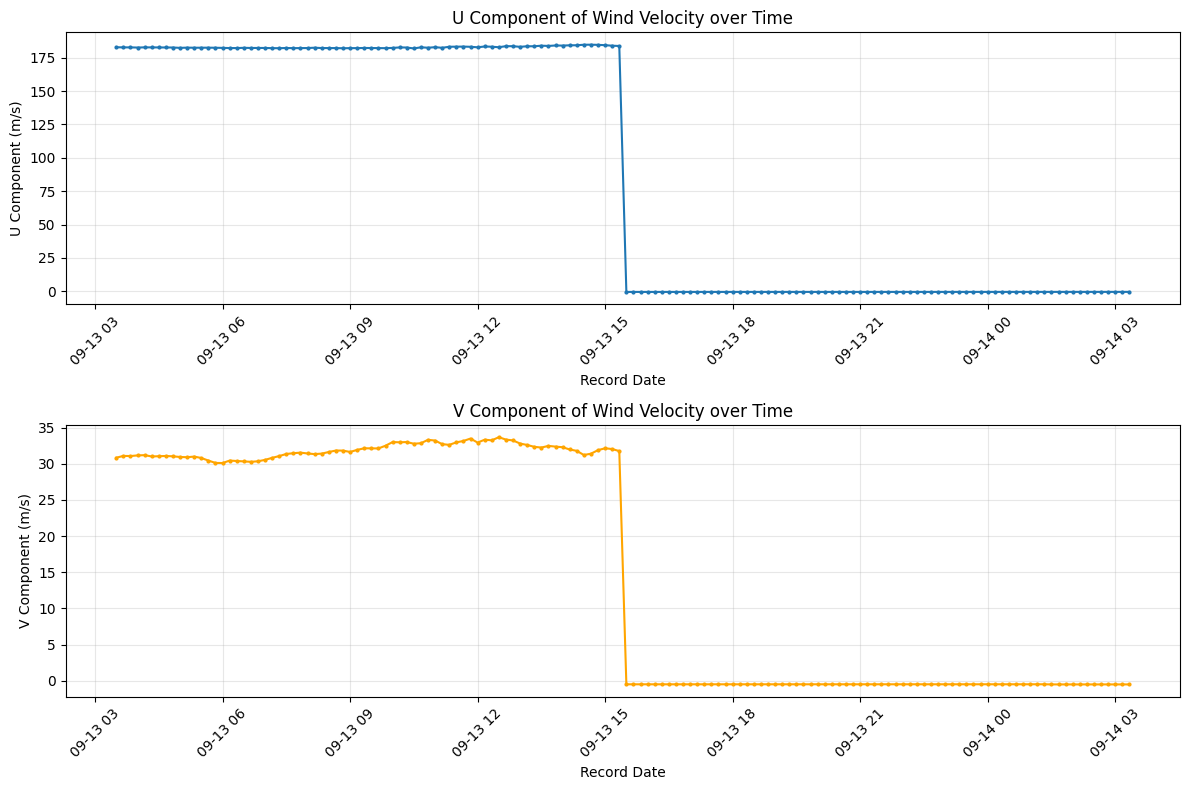

In [123]:
import matplotlib.pyplot as plt

# Create subplots for u and v components
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot u component
ax1.plot(single_turbine_df['record_date'], single_turbine_df['u'], marker='o', markersize=2)
ax1.set_title('U Component of Wind Velocity over Time')
ax1.set_xlabel('Record Date')
ax1.set_ylabel('U Component (m/s)')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Plot v component
ax2.plot(single_turbine_df['record_date'], single_turbine_df['v'], marker='o', markersize=2, color='orange')
ax2.set_title('V Component of Wind Velocity over Time')
ax2.set_xlabel('Record Date')
ax2.set_ylabel('V Component (m/s)')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
